First, we'll import the necessary libraries, download a sample image, and then proceed with Harris Corner Detection.

Image '/content/image.jpg' loaded successfully.


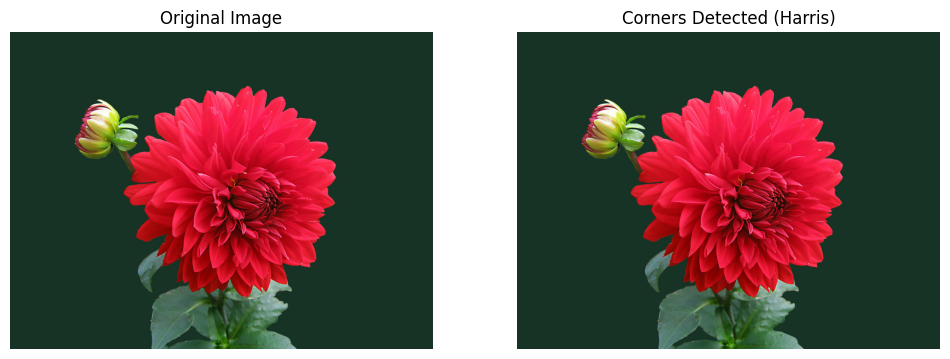

In [4]:
# Install opencv-python if not already installed
# !pip install opencv-python numpy matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Read the uploaded image
image_filename = '/content/image.jpg'
img = cv2.imread(image_filename)

if img is None:
    print(f"Error: Could not read the image from {image_filename}. Please make sure the file exists and is an image.")
else:
    print(f"Image '{image_filename}' loaded successfully.")

    # 3. Convert image to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Convert to float32 for Harris Corner Detector
    gray = np.float32(gray)

    # 4. Apply Harris Corner Detection
    # blockSize: It is the size of neighbourhoud considered for corner detection
    # ksize: Aperture parameter of Sobel derivative used.
    # k: Harris detector free parameter in the equation
    dst = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)

    # Result is dilated for marking the corners
    dst = cv2.dilate(dst, None)

    # Threshold for an optimal value, it may vary depending on the image.
    # Pixels above this threshold are marked as corners (in red).
    img_corners = img.copy()
    img_corners[dst > 0.01 * dst.max()] = [0, 0, 255] # Mark corners in red

    # 5. Display the original and the image with detected corners
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(img_corners, cv2.COLOR_BGR2RGB))
    plt.title('Corners Detected (Harris)')
    plt.axis('off')

    plt.show()